In [15]:
# ==========================================
# CELL 1: SETUP AND IMPORTS
# Run this cell to load necessary libraries 
# and configure the notebook environment.
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from nhlpy import NHLClient
from datetime import datetime, timedelta
import os
import subprocess

# Initialize the API client
client = NHLClient()

# Configure Pandas to display all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

# Configure Seaborn for aesthetic visual outputs
sns.set_theme(style="whitegrid", palette="muted")

print("[System] Libraries loaded successfully.")
print("[System] NHL API Client initialized and ready.")

[System] Libraries loaded successfully.
[System] NHL API Client initialized and ready.


In [16]:
# ==========================================
# CELL 2: CORE PARAMETERS
# Define the constraints for the analysis, including 
# controls for schedule fatigue and blowouts.
# ==========================================

TEAM_ABBR = "DET"
SEASON = "20252026"
EASTERN_CONFERENCE = [
    "BOS", "BUF", "FLA", "MTL", "OTT", "TBL", "TOR", # Atlantic
    "CAR", "CBJ", "NJD", "NYI", "NYR", "PHI", "PIT", "WSH"  # Metropolitan
]

# High Leverage & Confounder Constraints
PTS_PCT_THRESHOLD = 0.06  
MID_SEASON_BREAK = datetime.strptime("2026-02-06", "%Y-%m-%d") 
BLOWOUT_THRESHOLD = 5     
MIN_REST_DAYS = 1         

# The controlled variable: our specific group of skaters
CORE_COHORT = [
    "D. Larkin", "L. Raymond", "M. Seider", "M. Kasper", 
    "A. Copp", "S. Edvinsson", "E. Finnie", "A. DeBrincat", 
    "P. Kane", "B. Chiarot", "J. Compher"
]

print("[Config] Confounder controls active: /60 TOI Normalization, Blowout Elimination, Back-to-Back Elimination.")

[Config] Confounder controls active: /60 TOI Normalization, Blowout Elimination, Back-to-Back Elimination.


In [17]:
# ==========================================
# CELL 3: IDENTIFY HIGH STAKES GAMES (CLEANED)
# Iterate through the schedule, filter for leverage, 
# and strip out back-to-backs and blowouts.
# ==========================================

import requests # Bypassing the wrapper for stable historical standings

print(f"[Process] Fetching full {SEASON} schedule for {TEAM_ABBR}...")
schedule_data = client.schedule.team_season_schedule(team_abbr=TEAM_ABBR, season=SEASON)
games = schedule_data.get('games', [])

high_stakes_games = []
last_game_date = None

print(f"[Process] Evaluating {len(games)} games and stripping confounders...")

for game in games:
    game_id = str(game.get('id'))
    game_date_str = game.get('gameDate')
    game_date = datetime.strptime(game_date_str, "%Y-%m-%d")
    
    # 1. Calculate Rest Days (Schedule Fatigue Filter)
    if last_game_date:
        days_between = (game_date - last_game_date).days
        rest_days = days_between - 1
    else:
        rest_days = 99 
        
    last_game_date = game_date 
    
    # Filter 1: Regular season and Back-to-Back checks
    if game_id[4:6] != '02' or rest_days < MIN_REST_DAYS:
        continue
        
    # 2. Check Final Score (Score Effects / Blowout Filter)
    away_score = game.get('awayTeam', {}).get('score', 0)
    home_score = game.get('homeTeam', {}).get('score', 0)
    
    if abs(away_score - home_score) >= BLOWOUT_THRESHOLD:
        continue
    
    # Determine Opponent
    away_team = game.get('awayTeam', {}).get('abbrev')
    home_team = game.get('homeTeam', {}).get('abbrev')
    opponent = home_team if away_team == TEAM_ABBR else away_team
    
    # Filter 2: Eastern Conference Matchup
    # (Assuming you updated your constraints block to use EASTERN_CONFERENCE)
    if opponent not in EASTERN_CONFERENCE:
        continue
        
    # 3. Assess Leverage via Direct NHL Web API
    standings_date = (game_date - timedelta(days=1)).strftime("%Y-%m-%d")
    
    try:
        url = f"https://api-web.nhle.com/v1/standings/{standings_date}"
        response = requests.get(url)
        response.raise_for_status() # Catch any HTTP errors safely
        daily_standings = response.json().get('standings', [])
        
        det_pts_pct, opp_pts_pct = None, None
        
        for team in daily_standings:
            team_abbrev = team.get('teamAbbrev', {}).get('default', '')
                
            if team_abbrev == TEAM_ABBR:
                det_pts_pct = team.get('pointPctg', 0.0)
            elif team_abbrev == opponent:
                opp_pts_pct = team.get('pointPctg', 0.0)
                
        # Filter 3: Points Percentage differential
        if det_pts_pct is not None and opp_pts_pct is not None:
            pts_pct_diff = abs(det_pts_pct - opp_pts_pct)
            
            if pts_pct_diff <= PTS_PCT_THRESHOLD:
                season_phase = "Early Season" if game_date < MID_SEASON_BREAK else "Late Season"
                
                high_stakes_games.append({
                    'game_id': game_id,
                    'date': game_date_str,
                    'opponent': opponent,
                    'det_pts_pct': det_pts_pct,
                    'opp_pts_pct': opp_pts_pct,
                    'pts_pct_diff': round(pts_pct_diff, 4),
                    'rest_days': rest_days,
                    'season_phase': season_phase
                })
    except Exception as e:
        print(f"[Warning] Failed to fetch data for {standings_date}. Error: {e}")

df_high_stakes = pd.DataFrame(high_stakes_games)
print(f"\n[Result] Discovered {len(df_high_stakes)} pristine high-leverage games.")
if len(df_high_stakes) > 0:
    display(df_high_stakes.head())

[Process] Fetching full 20252026 schedule for DET...
[Process] Evaluating 90 games and stripping confounders...

[Result] Discovered 22 pristine high-leverage games.


,game_id,date,opponent,det_pts_pct,opp_pts_pct,pts_pct_diff,rest_days,season_phase
0,2025020010,2025-10-09,MTL,0.000000,0.000000,0.0000,4,Early Season
1,2025020043,2025-10-13,TOR,0.500000,0.500000,0.0000,1,Early Season
2,2025020335,2025-11-22,CBJ,0.595238,0.571429,0.0238,1,Early Season
3,2025020354,2025-11-24,NJD,0.613636,0.642857,0.0292,1,Early Season
4,2025020412,2025-12-02,BOS,0.538462,0.555556,0.0171,2,Early Season


In [18]:
# ==========================================
# CELL 4: EXTRACT & NORMALIZE BEHAVIORAL PROXIES (ANTI-BOT CLOAKED)
# Bypasses NHL server firewalls by mimicking a standard web browser,
# and includes a 3-strike retry system for server timeouts.
# ==========================================

import requests
import time

telemetry_records = []
total_games = len(df_high_stakes)

# Mimic a real web browser to bypass the NHL's anti-bot tarpit
HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36",
    "Accept": "application/json",
    "Accept-Language": "en-US,en;q=0.9"
}

print(f"[Process] Querying and normalizing player-level behavioral metrics for {total_games} games...")

for index, row in df_high_stakes.iterrows():
    game_id = row['game_id']
    print(f"     [Status] Fetching Game {game_id} ({index + 1}/{total_games})...")
    
    url = f"https://api-web.nhle.com/v1/gamecenter/{game_id}/boxscore"
    max_retries = 3
    
    for attempt in range(max_retries):
        try:
            # Pass the fake browser headers and a 15-second timeout
            response = requests.get(url, headers=HEADERS, timeout=15)
            response.raise_for_status()
            game_stats = response.json()
            
            away_team_abbrev = game_stats.get('awayTeam', {}).get('abbrev')
            target_team_key = 'awayTeam' if away_team_abbrev == TEAM_ABBR else 'homeTeam'
            
            player_groups = game_stats.get('playerByGameStats', {}).get(target_team_key, {})
            all_skaters = player_groups.get('forwards', []) + player_groups.get('defense', [])
            
            for player in all_skaters:
                first_name = player.get('firstName', {}).get('default', '')
                last_name = player.get('lastName', {}).get('default', '')
                constructed_name = f"{first_name} {last_name}".strip()
                single_name = player.get('name', {}).get('default', '')
                player_name = constructed_name if constructed_name else single_name
                
                if player_name in CORE_COHORT:
                    toi_str = player.get('toi', '00:00')
                    raw_sog = player.get('sog', 0)
                    raw_blocks = player.get('blockedShots', 0)
                    
                    try:
                        minutes, seconds = map(int, toi_str.split(':'))
                        toi_decimal = minutes + (seconds / 60.0)
                    except ValueError:
                        toi_decimal = 0.0
                    
                    if toi_decimal == 0:
                        continue
                    
                    telemetry_records.append({
                        'game_id': game_id,
                        'player_name': player_name,
                        'toi_minutes': round(toi_decimal, 2),
                        'sog_per_60': (raw_sog / toi_decimal) * 60,
                        'blocks_per_60': (raw_blocks / toi_decimal) * 60
                    })
            
            time.sleep(1) # Wait 1 second before hitting the next game to stay under the radar
            break # Break out of the retry loop if successful!
            
        except requests.exceptions.Timeout:
            if attempt < max_retries - 1:
                print(f"          [Retry] Timeout on {game_id}. The server is sluggish. Retrying in 3 seconds... ({attempt+1}/{max_retries})")
                time.sleep(3)
            else:
                print(f"     [Error] NHL API completely blocked Game {game_id} after {max_retries} attempts.")
        except Exception as e:
            print(f"     [Error] Failed on Game {game_id}. Details: {e}")
            break # Break on non-timeout errors so we don't spam a broken endpoint

df_telemetry = pd.DataFrame(telemetry_records)

print(f"\n[Result] Extracted metrics for {len(df_telemetry)} player-game combinations.")
if len(df_telemetry) > 0:
    display(df_telemetry.head())

[Process] Querying and normalizing player-level behavioral metrics for 22 games...
     [Status] Fetching Game 2025020010 (1/22)...
     [Status] Fetching Game 2025020043 (2/22)...
     [Status] Fetching Game 2025020335 (3/22)...
     [Status] Fetching Game 2025020354 (4/22)...
     [Status] Fetching Game 2025020412 (5/22)...
     [Status] Fetching Game 2025020432 (6/22)...
     [Status] Fetching Game 2025020522 (7/22)...
     [Status] Fetching Game 2025020550 (8/22)...
     [Status] Fetching Game 2025020593 (9/22)...
     [Status] Fetching Game 2025020644 (10/22)...
     [Status] Fetching Game 2025020664 (11/22)...
     [Status] Fetching Game 2025020703 (12/22)...
     [Status] Fetching Game 2025020717 (13/22)...
     [Status] Fetching Game 2025021030 (14/22)...
     [Status] Fetching Game 2025021085 (15/22)...
     [Status] Fetching Game 2025021108 (16/22)...
     [Status] Fetching Game 2025021122 (17/22)...
     [Status] Fetching Game 2025021183 (18/22)...
     [Status] Fetching Gam

,game_id,player_name,toi_minutes,sog_per_60,blocks_per_60
0,2025020010,A. Copp,16.05,3.738318,3.738318
1,2025020010,L. Raymond,17.87,6.716418,3.358209
2,2025020010,J. Compher,14.78,4.058625,8.117249
3,2025020010,E. Finnie,12.37,4.851752,0.000000
4,2025020010,D. Larkin,18.33,16.363636,0.000000


In [19]:
# ==========================================
# CELL 5: DATA MERGE & STATISTICAL TESTING
# Merge datasets, calculate the behavioral proxy footprint,
# and run Welch's t-test for statistical significance.
# ==========================================

from scipy import stats

print("[Process] Aggregating behavioral metrics to game-level cohort averages...")

# 1. Aggregate player data up to the Game level
cohort_game_averages = df_telemetry.groupby('game_id').agg(
    cohort_avg_sog_per_60=('sog_per_60', 'mean'),
    cohort_avg_blocks_per_60=('blocks_per_60', 'mean')
).reset_index()

# 2. Merge to create the master dataset used for testing and visuals
df_master = pd.merge(df_high_stakes, cohort_game_averages, on='game_id', how='inner')

# 3. Aggregate by Season Phase for the Summary Table
analysis_summary = df_master.groupby('season_phase').agg(
    games_analyzed=('game_id', 'count'),
    phase_avg_sog_per_60=('cohort_avg_sog_per_60', 'mean'),
    phase_avg_blocks_per_60=('cohort_avg_blocks_per_60', 'mean')
).reset_index()

# Sort to ensure Early Season appears before Late Season
analysis_summary['sort_order'] = analysis_summary['season_phase'].apply(lambda x: 1 if x == 'Early Season' else 2)
analysis_summary = analysis_summary.sort_values('sort_order').drop(columns=['sort_order'])

print("\n--- MASTER COHORT SUMMARY ---")
display(analysis_summary)

# 4. Statistical Testing
print("\n--- STATISTICAL SIGNIFICANCE (WELCH'S T-TEST) ---")

early_games = df_master[df_master['season_phase'] == 'Early Season']
late_games = df_master[df_master['season_phase'] == 'Late Season']

def run_test(metric_name, early_data, late_data):
    if len(early_data) > 1 and len(late_data) > 1:
        t_stat, p_value = stats.ttest_ind(early_data, late_data, equal_var=False)
        sig = "STATISTICALLY SIGNIFICANT" if p_value < 0.05 else "NOT SIGNIFICANT"
        print(f"[{metric_name}] P-Value: {p_value:.4f} -> {sig}")
    else:
        print(f"[{metric_name}] Not enough data to run t-test.")

run_test("Hesitation Metric (SOG/60)", early_games['cohort_avg_sog_per_60'].dropna(), late_games['cohort_avg_sog_per_60'].dropna())
run_test("Structural Tightening (Blocks/60)", early_games['cohort_avg_blocks_per_60'].dropna(), late_games['cohort_avg_blocks_per_60'].dropna())

[Process] Aggregating behavioral metrics to game-level cohort averages...

--- MASTER COHORT SUMMARY ---


,season_phase,games_analyzed,phase_avg_sog_per_60,phase_avg_blocks_per_60
0,Early Season,13,5.612377,3.259484
1,Late Season,9,6.330794,2.665671



--- STATISTICAL SIGNIFICANCE (WELCH'S T-TEST) ---
[Hesitation Metric (SOG/60)] P-Value: 0.3599 -> NOT SIGNIFICANT
[Structural Tightening (Blocks/60)] P-Value: 0.2458 -> NOT SIGNIFICANT


[Success] Visualizations rendered and saved as 'behavioral_footprint_visuals.png'.


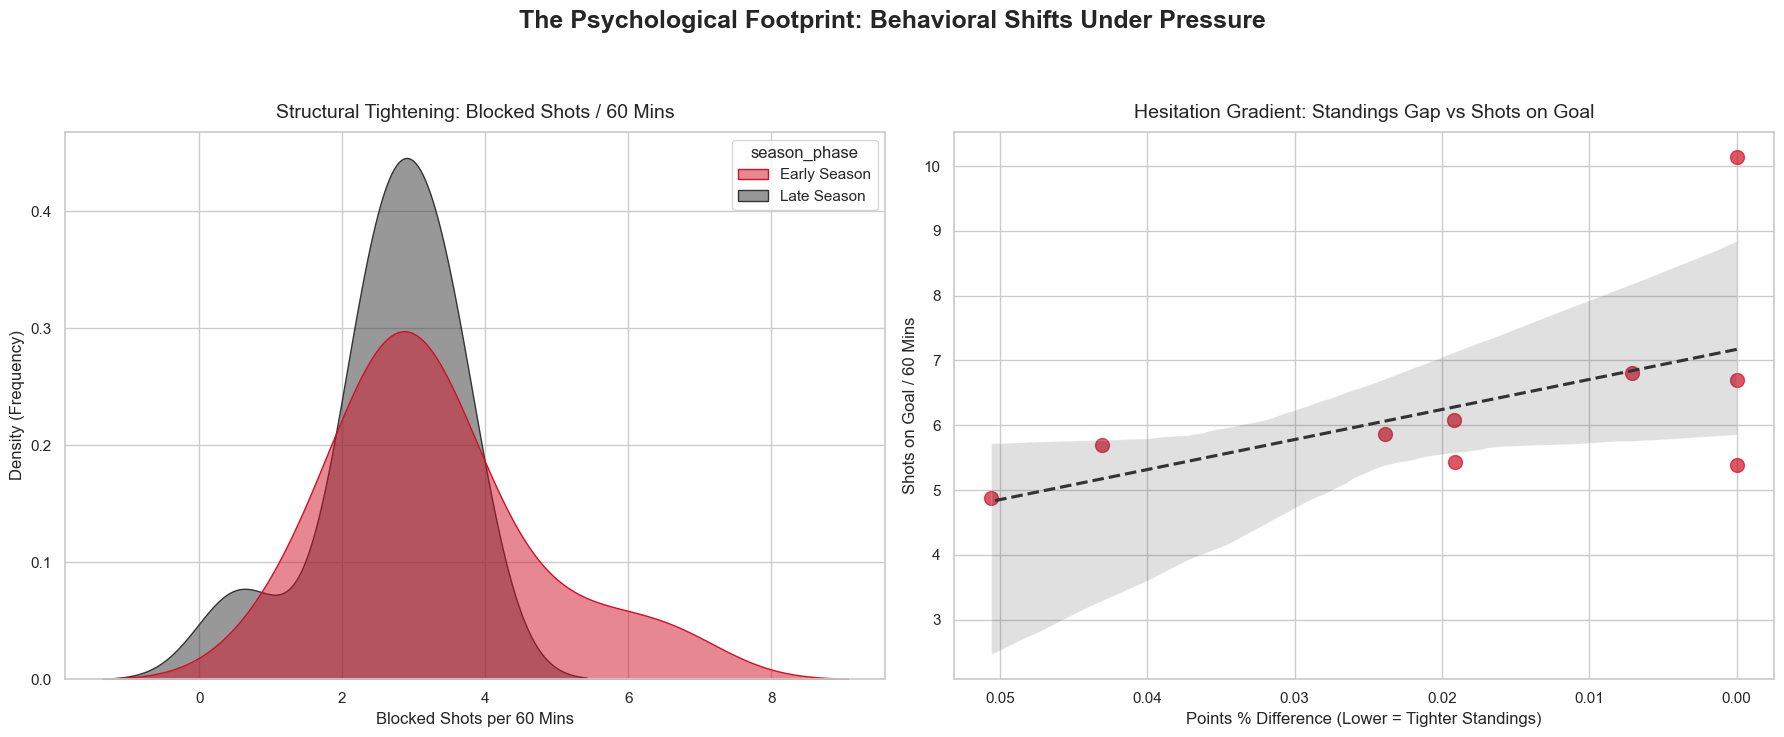

In [20]:
# ==========================================
# CELL 6: BEHAVIORAL PROXY VISUALIZATIONS
# Generate professional charts for portfolio presentation.
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

# Set custom colors for Detroit Red Wings
red_wings_palette = {'Early Season': '#CE1126', 'Late Season': '#333333'}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('The Psychological Footprint: Behavioral Shifts Under Pressure', fontsize=18, fontweight='bold', y=1.05)

# --- CHART 1: KDE Distribution Shift (Blocked Shots) ---
sns.kdeplot(
    data=df_master, x='cohort_avg_blocks_per_60', hue='season_phase', 
    fill=True, common_norm=False, palette=red_wings_palette, alpha=0.5, ax=axes[0]
)
axes[0].set_title('Structural Tightening: Blocked Shots / 60 Mins', fontsize=14, pad=10)
axes[0].set_xlabel('Blocked Shots per 60 Mins', fontsize=12)
axes[0].set_ylabel('Density (Frequency)', fontsize=12)

# --- CHART 2: Regression Gradient (Shots on Goal) ---
late_season_df = df_master[df_master['season_phase'] == 'Late Season']
sns.regplot(
    data=late_season_df, x='pts_pct_diff', y='cohort_avg_sog_per_60',
    scatter_kws={'s': 100, 'alpha': 0.7, 'color': '#CE1126'},
    line_kws={'color': '#333333', 'linestyle': '--'}, ax=axes[1]
)
axes[1].invert_xaxis() # Tighter standings on the right
axes[1].set_title('Hesitation Gradient: Standings Gap vs Shots on Goal', fontsize=14, pad=10)
axes[1].set_xlabel('Points % Difference (Lower = Tighter Standings)', fontsize=12)
axes[1].set_ylabel('Shots on Goal / 60 Mins', fontsize=12)

plt.tight_layout()

# Save the plot as an image file in the local directory for GitHub
plt.savefig('behavioral_footprint_visuals.png', bbox_inches='tight', dpi=300)
print("[Success] Visualizations rendered and saved as 'behavioral_footprint_visuals.png'.")
plt.show()

In [9]:
# ==========================================
# CELL 2: CORE PARAMETERS (MONTREAL BENCHMARK)
# ==========================================

TEAM_ABBR = "MTL"
SEASON = "20252026"

# Constrain back to the Eastern Conference for Montreal
EASTERN_CONFERENCE = [
    "BOS", "BUF", "FLA", "MTL", "OTT", "TBL", "TOR", # Atlantic
    "CAR", "CBJ", "NJD", "NYI", "NYR", "PHI", "PIT", "WSH"  # Metropolitan
]

# High Leverage Constraints (Kept identical to Detroit)
PTS_PCT_THRESHOLD = 0.06  
MID_SEASON_BREAK = datetime.strptime("2026-02-06", "%Y-%m-%d") 
BLOWOUT_THRESHOLD = 5     
MIN_REST_DAYS = 1         

# Montreal Canadiens Core Cohort
CORE_COHORT = [
    "N. Suzuki", "C. Caufield", "J. Slafkovsky", "M. Matheson", 
    "K. Guhle", "K. Dach", "A. Newhook", "B. Gallagher", "D. Savard"
]

print("[Config] Montreal Canadiens benchmark parameters loaded.")

[Config] Montreal Canadiens benchmark parameters loaded.


In [10]:
# ==========================================
# CELL 3: IDENTIFY HIGH STAKES GAMES (CLEANED)
# Iterate through the schedule, filter for leverage, 
# and strip out back-to-backs and blowouts.
# ==========================================

import requests # Bypassing the wrapper for stable historical standings

print(f"[Process] Fetching full {SEASON} schedule for {TEAM_ABBR}...")
schedule_data = client.schedule.team_season_schedule(team_abbr=TEAM_ABBR, season=SEASON)
games = schedule_data.get('games', [])

high_stakes_games = []
last_game_date = None

print(f"[Process] Evaluating {len(games)} games and stripping confounders...")

for game in games:
    game_id = str(game.get('id'))
    game_date_str = game.get('gameDate')
    game_date = datetime.strptime(game_date_str, "%Y-%m-%d")
    
    # 1. Calculate Rest Days (Schedule Fatigue Filter)
    if last_game_date:
        days_between = (game_date - last_game_date).days
        rest_days = days_between - 1
    else:
        rest_days = 99 
        
    last_game_date = game_date 
    
    # Filter 1: Regular season and Back-to-Back checks
    if game_id[4:6] != '02' or rest_days < MIN_REST_DAYS:
        continue
        
    # 2. Check Final Score (Score Effects / Blowout Filter)
    away_score = game.get('awayTeam', {}).get('score', 0)
    home_score = game.get('homeTeam', {}).get('score', 0)
    
    if abs(away_score - home_score) >= BLOWOUT_THRESHOLD:
        continue
    
    # Determine Opponent
    away_team = game.get('awayTeam', {}).get('abbrev')
    home_team = game.get('homeTeam', {}).get('abbrev')
    opponent = home_team if away_team == TEAM_ABBR else away_team
    
    # Filter 2: Eastern Conference Matchup
    # (Assuming you updated your constraints block to use EASTERN_CONFERENCE)
    if opponent not in EASTERN_CONFERENCE:
        continue
        
    # 3. Assess Leverage via Direct NHL Web API
    standings_date = (game_date - timedelta(days=1)).strftime("%Y-%m-%d")
    
    try:
        url = f"https://api-web.nhle.com/v1/standings/{standings_date}"
        response = requests.get(url)
        response.raise_for_status() # Catch any HTTP errors safely
        daily_standings = response.json().get('standings', [])
        
        det_pts_pct, opp_pts_pct = None, None
        
        for team in daily_standings:
            team_abbrev = team.get('teamAbbrev', {}).get('default', '')
                
            if team_abbrev == TEAM_ABBR:
                det_pts_pct = team.get('pointPctg', 0.0)
            elif team_abbrev == opponent:
                opp_pts_pct = team.get('pointPctg', 0.0)
                
        # Filter 3: Points Percentage differential
        if det_pts_pct is not None and opp_pts_pct is not None:
            pts_pct_diff = abs(det_pts_pct - opp_pts_pct)
            
            if pts_pct_diff <= PTS_PCT_THRESHOLD:
                season_phase = "Early Season" if game_date < MID_SEASON_BREAK else "Late Season"
                
                high_stakes_games.append({
                    'game_id': game_id,
                    'date': game_date_str,
                    'opponent': opponent,
                    'det_pts_pct': det_pts_pct,
                    'opp_pts_pct': opp_pts_pct,
                    'pts_pct_diff': round(pts_pct_diff, 4),
                    'rest_days': rest_days,
                    'season_phase': season_phase
                })
    except Exception as e:
        print(f"[Warning] Failed to fetch data for {standings_date}. Error: {e}")

df_high_stakes = pd.DataFrame(high_stakes_games)
print(f"\n[Result] Discovered {len(df_high_stakes)} pristine high-leverage games.")
if len(df_high_stakes) > 0:
    display(df_high_stakes.head())

[Process] Fetching full 20252026 schedule for MTL...
[Process] Evaluating 88 games and stripping confounders...

[Result] Discovered 24 pristine high-leverage games.


,game_id,date,opponent,det_pts_pct,opp_pts_pct,pts_pct_diff,rest_days,season_phase
0,2025020004,2025-10-08,TOR,0.000000,0.000000,0.0000,3,Early Season
1,2025020220,2025-11-06,NJD,0.730769,0.692308,0.0385,1,Early Season
2,2025020305,2025-11-17,CBJ,0.611111,0.555556,0.0556,1,Early Season
3,2025020320,2025-11-20,WSH,0.605263,0.550000,0.0553,2,Early Season
4,2025020411,2025-12-02,OTT,0.604167,0.560000,0.0442,2,Early Season


In [11]:
# ==========================================
# CELL 4: EXTRACT & NORMALIZE BEHAVIORAL PROXIES (ANTI-BOT CLOAKED)
# Bypasses NHL server firewalls by mimicking a standard web browser,
# and includes a 3-strike retry system for server timeouts.
# ==========================================

import requests
import time

telemetry_records = []
total_games = len(df_high_stakes)

# Mimic a real web browser to bypass the NHL's anti-bot tarpit
HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36",
    "Accept": "application/json",
    "Accept-Language": "en-US,en;q=0.9"
}

print(f"[Process] Querying and normalizing player-level behavioral metrics for {total_games} games...")

for index, row in df_high_stakes.iterrows():
    game_id = row['game_id']
    print(f"     [Status] Fetching Game {game_id} ({index + 1}/{total_games})...")
    
    url = f"https://api-web.nhle.com/v1/gamecenter/{game_id}/boxscore"
    max_retries = 3
    
    for attempt in range(max_retries):
        try:
            # Pass the fake browser headers and a 15-second timeout
            response = requests.get(url, headers=HEADERS, timeout=15)
            response.raise_for_status()
            game_stats = response.json()
            
            away_team_abbrev = game_stats.get('awayTeam', {}).get('abbrev')
            target_team_key = 'awayTeam' if away_team_abbrev == TEAM_ABBR else 'homeTeam'
            
            player_groups = game_stats.get('playerByGameStats', {}).get(target_team_key, {})
            all_skaters = player_groups.get('forwards', []) + player_groups.get('defense', [])
            
            for player in all_skaters:
                first_name = player.get('firstName', {}).get('default', '')
                last_name = player.get('lastName', {}).get('default', '')
                constructed_name = f"{first_name} {last_name}".strip()
                single_name = player.get('name', {}).get('default', '')
                player_name = constructed_name if constructed_name else single_name
                
                if player_name in CORE_COHORT:
                    toi_str = player.get('toi', '00:00')
                    raw_sog = player.get('sog', 0)
                    raw_blocks = player.get('blockedShots', 0)
                    
                    try:
                        minutes, seconds = map(int, toi_str.split(':'))
                        toi_decimal = minutes + (seconds / 60.0)
                    except ValueError:
                        toi_decimal = 0.0
                    
                    if toi_decimal == 0:
                        continue
                    
                    telemetry_records.append({
                        'game_id': game_id,
                        'player_name': player_name,
                        'toi_minutes': round(toi_decimal, 2),
                        'sog_per_60': (raw_sog / toi_decimal) * 60,
                        'blocks_per_60': (raw_blocks / toi_decimal) * 60
                    })
            
            time.sleep(1) # Wait 1 second before hitting the next game to stay under the radar
            break # Break out of the retry loop if successful!
            
        except requests.exceptions.Timeout:
            if attempt < max_retries - 1:
                print(f"          [Retry] Timeout on {game_id}. The server is sluggish. Retrying in 3 seconds... ({attempt+1}/{max_retries})")
                time.sleep(3)
            else:
                print(f"     [Error] NHL API completely blocked Game {game_id} after {max_retries} attempts.")
        except Exception as e:
            print(f"     [Error] Failed on Game {game_id}. Details: {e}")
            break # Break on non-timeout errors so we don't spam a broken endpoint

df_telemetry = pd.DataFrame(telemetry_records)

print(f"\n[Result] Extracted metrics for {len(df_telemetry)} player-game combinations.")
if len(df_telemetry) > 0:
    display(df_telemetry.head())

[Process] Querying and normalizing player-level behavioral metrics for 24 games...
     [Status] Fetching Game 2025020004 (1/24)...
     [Status] Fetching Game 2025020220 (2/24)...
     [Status] Fetching Game 2025020305 (3/24)...
     [Status] Fetching Game 2025020320 (4/24)...
     [Status] Fetching Game 2025020411 (5/24)...
     [Status] Fetching Game 2025020444 (6/24)...
     [Status] Fetching Game 2025020484 (7/24)...
     [Status] Fetching Game 2025020500 (8/24)...
     [Status] Fetching Game 2025020521 (9/24)...
     [Status] Fetching Game 2025020556 (10/24)...
     [Status] Fetching Game 2025020577 (11/24)...
     [Status] Fetching Game 2025020602 (12/24)...
     [Status] Fetching Game 2025020618 (13/24)...
     [Status] Fetching Game 2025020636 (14/24)...
     [Status] Fetching Game 2025020740 (15/24)...
     [Status] Fetching Game 2025020795 (16/24)...
     [Status] Fetching Game 2025020812 (17/24)...
     [Status] Fetching Game 2025020865 (18/24)...
     [Status] Fetching Gam

,game_id,player_name,toi_minutes,sog_per_60,blocks_per_60
0,2025020004,B. Gallagher,13.53,4.433498,4.433498
1,2025020004,C. Caufield,20.38,11.774325,0.000000
2,2025020004,N. Suzuki,20.70,5.797101,2.898551
3,2025020004,A. Newhook,15.25,3.934426,0.000000
4,2025020004,K. Dach,11.78,10.183876,15.275813


In [12]:
# ==========================================
# CELL 5: DATA MERGE & STATISTICAL TESTING
# Merge datasets, calculate the behavioral proxy footprint,
# and run Welch's t-test for statistical significance.
# ==========================================

from scipy import stats

print("[Process] Aggregating behavioral metrics to game-level cohort averages...")

# 1. Aggregate player data up to the Game level
cohort_game_averages = df_telemetry.groupby('game_id').agg(
    cohort_avg_sog_per_60=('sog_per_60', 'mean'),
    cohort_avg_blocks_per_60=('blocks_per_60', 'mean')
).reset_index()

# 2. Merge to create the master dataset used for testing and visuals
df_master = pd.merge(df_high_stakes, cohort_game_averages, on='game_id', how='inner')

# 3. Aggregate by Season Phase for the Summary Table
analysis_summary = df_master.groupby('season_phase').agg(
    games_analyzed=('game_id', 'count'),
    phase_avg_sog_per_60=('cohort_avg_sog_per_60', 'mean'),
    phase_avg_blocks_per_60=('cohort_avg_blocks_per_60', 'mean')
).reset_index()

# Sort to ensure Early Season appears before Late Season
analysis_summary['sort_order'] = analysis_summary['season_phase'].apply(lambda x: 1 if x == 'Early Season' else 2)
analysis_summary = analysis_summary.sort_values('sort_order').drop(columns=['sort_order'])

print("\n--- MASTER COHORT SUMMARY ---")
display(analysis_summary)

# 4. Statistical Testing
print("\n--- STATISTICAL SIGNIFICANCE (WELCH'S T-TEST) ---")

early_games = df_master[df_master['season_phase'] == 'Early Season']
late_games = df_master[df_master['season_phase'] == 'Late Season']

def run_test(metric_name, early_data, late_data):
    if len(early_data) > 1 and len(late_data) > 1:
        t_stat, p_value = stats.ttest_ind(early_data, late_data, equal_var=False)
        sig = "STATISTICALLY SIGNIFICANT" if p_value < 0.05 else "NOT SIGNIFICANT"
        print(f"[{metric_name}] P-Value: {p_value:.4f} -> {sig}")
    else:
        print(f"[{metric_name}] Not enough data to run t-test.")

run_test("Hesitation Metric (SOG/60)", early_games['cohort_avg_sog_per_60'].dropna(), late_games['cohort_avg_sog_per_60'].dropna())
run_test("Structural Tightening (Blocks/60)", early_games['cohort_avg_blocks_per_60'].dropna(), late_games['cohort_avg_blocks_per_60'].dropna())

[Process] Aggregating behavioral metrics to game-level cohort averages...

--- MASTER COHORT SUMMARY ---


,season_phase,games_analyzed,phase_avg_sog_per_60,phase_avg_blocks_per_60
0,Early Season,18,7.083687,2.078326
1,Late Season,6,6.872999,3.393985



--- STATISTICAL SIGNIFICANCE (WELCH'S T-TEST) ---
[Hesitation Metric (SOG/60)] P-Value: 0.8403 -> NOT SIGNIFICANT
[Structural Tightening (Blocks/60)] P-Value: 0.1939 -> NOT SIGNIFICANT


[Success] Visualizations rendered and saved as 'montreal_behavioral_footprint.png'.


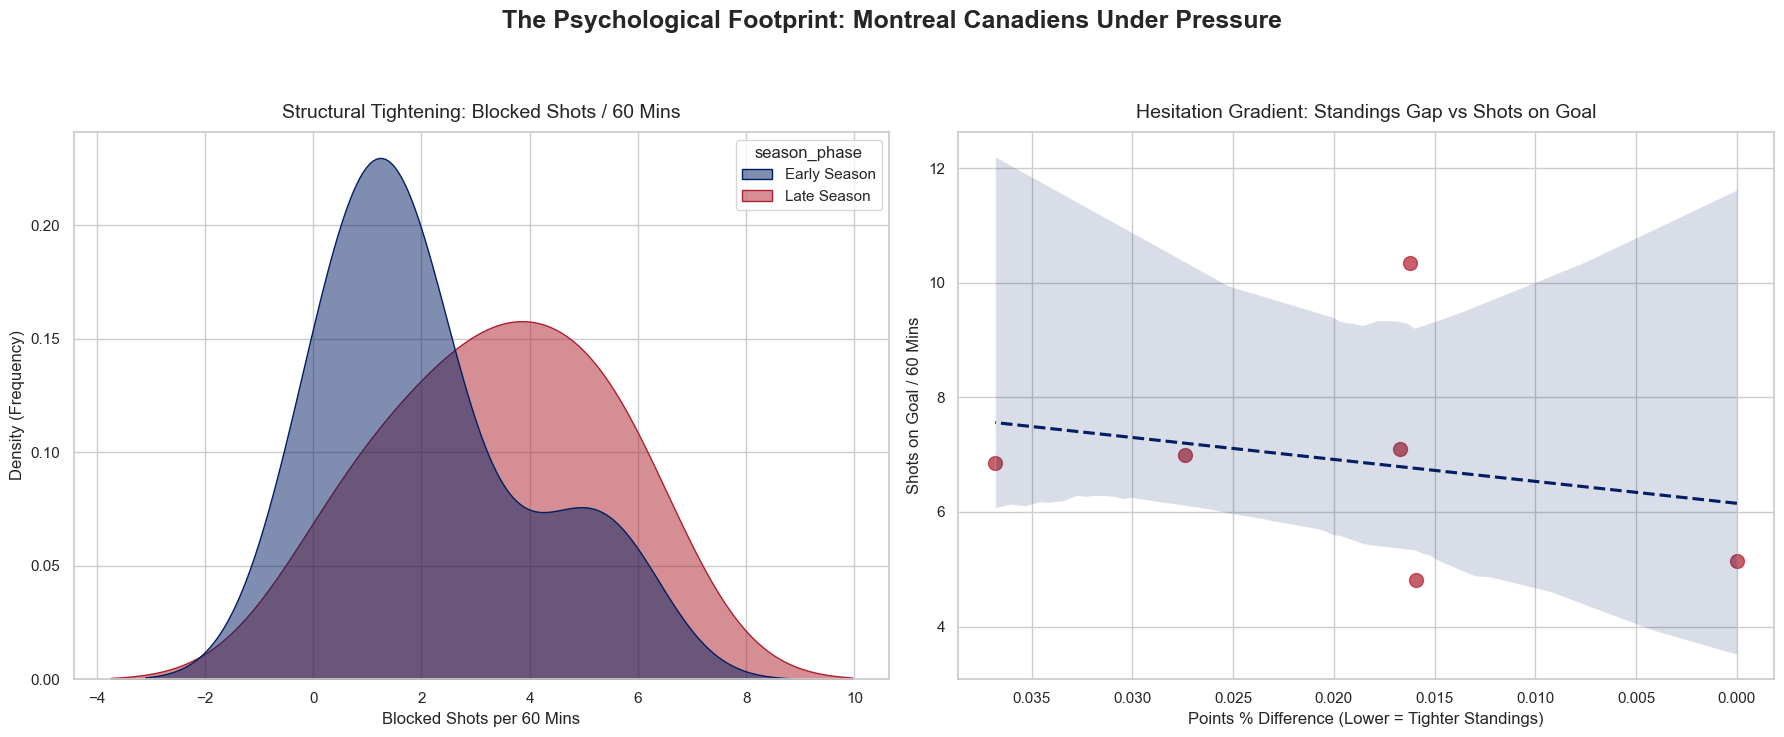

In [14]:
# ==========================================
# CELL 6: BEHAVIORAL PROXY VISUALIZATIONS (MONTREAL CANADIENS)
# Generate professional charts for portfolio presentation.
# ==========================================

import matplotlib.pyplot as plt
import seaborn as sns

# Set custom colors for Montreal Canadiens
habs_palette = {'Early Season': '#001E62', 'Late Season': '#AF1E2D'}

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('The Psychological Footprint: Montreal Canadiens Under Pressure', fontsize=18, fontweight='bold', y=1.05)

# --- CHART 1: KDE Distribution Shift (Blocked Shots) ---
sns.kdeplot(
    data=df_master, x='cohort_avg_blocks_per_60', hue='season_phase', 
    fill=True, common_norm=False, palette=habs_palette, alpha=0.5, ax=axes[0]
)
axes[0].set_title('Structural Tightening: Blocked Shots / 60 Mins', fontsize=14, pad=10)
axes[0].set_xlabel('Blocked Shots per 60 Mins', fontsize=12)
axes[0].set_ylabel('Density (Frequency)', fontsize=12)

# --- CHART 2: Regression Gradient (Shots on Goal) ---
late_season_df = df_master[df_master['season_phase'] == 'Late Season']
sns.regplot(
    data=late_season_df, x='pts_pct_diff', y='cohort_avg_sog_per_60',
    scatter_kws={'s': 100, 'alpha': 0.7, 'color': '#AF1E2D'},
    line_kws={'color': '#001E62', 'linestyle': '--'}, ax=axes[1]
)
axes[1].invert_xaxis() # Tighter standings on the right
axes[1].set_title('Hesitation Gradient: Standings Gap vs Shots on Goal', fontsize=14, pad=10)
axes[1].set_xlabel('Points % Difference (Lower = Tighter Standings)', fontsize=12)
axes[1].set_ylabel('Shots on Goal / 60 Mins', fontsize=12)

plt.tight_layout()

# Save the plot as an image file in the local directory for GitHub
plt.savefig('montreal_behavioral_footprint.png', bbox_inches='tight', dpi=300)
print("[Success] Visualizations rendered and saved as 'montreal_behavioral_footprint.png'.")